# **AI-ML TRAINING PROJECT WORK **



**TOPIC : “Give Me Some Credit – Default Prediction” task (predict financial distress within two years)**

 *Objective:
Predict whether a borrower will experience financial distress (default) within the next 2 years.*

Note : We use train.csv because it contains both the features and the target variable.We do not use test.csv for training because it does not contain the target column. It is only used to make predictions on unseen data and evaluate how well the trained model generalizes.

Using test data for training would cause data leakage and unreliable resul

Target Variable

SeriousDlqin2yrs

1 → Person defaulted

0 → Person did not default

In [31]:
# All Required Modules
import pandas as pd

In [32]:
train = pd.read_csv('/content/drive/MyDrive/AIML PROJECT/credit.csv') # Training data
train

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [33]:
# Show rows with age <= 0
print(train[train['age'] <= 0])

# Show rows with age > 100 (optional)
print(train[train['age'] > 100])


       Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  \
65695       65696                 0                                   1.0   

       age  NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
65695    0                                     1   0.436927         6000.0   

       NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
65695                                6                        0   

       NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  \
65695                             2                                     0   

       NumberOfDependents  
65695                 2.0  
        Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  \
7763          7764                 0                              0.069167   
19884        19885                 0                              1.000000   
25561        25562                 0                              0.009866   
40007        40008            

In [34]:
# Drop age = 0 (invalid)
train = train[train['age'] > 0]

# Cap maximum age to 100 (optional) to remove extreme outliers
train = train[train['age'] <= 100]


In [35]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149986 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            149986 non-null  int64  
 1   SeriousDlqin2yrs                      149986 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  149986 non-null  float64
 3   age                                   149986 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  149986 non-null  int64  
 5   DebtRatio                             149986 non-null  float64
 6   MonthlyIncome                         120262 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       149986 non-null  int64  
 8   NumberOfTimes90DaysLate               149986 non-null  int64  
 9   NumberRealEstateLoansOrLines          149986 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  149986 non-null  int64  
 11  Numbe

In [36]:
train.describe()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,1.202620e+05,149986.000000,149986.000000,149986.000000,149986.000000,146065.000000
mean,75000.499467,0.066840,6.048985,52.291101,0.421053,353.002995,6.670453e+03,8.452922,0.265998,1.018295,0.240409,0.757259
std,43301.645266,0.249745,249.767020,14.764163,4.192973,2037.902441,1.438505e+04,5.146013,4.169498,1.129787,4.155373,1.115107
min,1.000000,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.250000,0.000000,0.029878,41.000000,0.000000,0.175075,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154234,52.000000,0.000000,0.366503,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.750000,0.000000,0.559053,63.000000,0.000000,0.868100,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,99.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [37]:
train.shape


(149986, 12)

In [38]:
# Drop index column if present
if 'Unnamed: 0' in train.columns:
    train.drop('Unnamed: 0', axis=1, inplace=True)


In [39]:
# Check missing values column-wise
print(train.isnull().sum())


SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29724
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3921
dtype: int64


In [40]:
# Fill numeric missing values using median
train.fillna(train.median(numeric_only=True), inplace=True)



In [41]:
# Confirm no missing values left
print(train.isnull().sum())


SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [42]:
# Check target distribution
print(train['SeriousDlqin2yrs'].value_counts(normalize=True))


SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [43]:
#no of outliers
import numpy as np
import pandas as pd

df = train.drop('SeriousDlqin2yrs', axis=1)

for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "->", outliers.shape[0], "outliers")


RevolvingUtilizationOfUnsecuredLines -> 763 outliers
age -> 32 outliers
NumberOfTime30-59DaysPastDueNotWorse -> 23980 outliers
DebtRatio -> 31304 outliers
MonthlyIncome -> 9149 outliers
NumberOfOpenCreditLinesAndLoans -> 3980 outliers
NumberOfTimes90DaysLate -> 8338 outliers
NumberRealEstateLoansOrLines -> 793 outliers
NumberOfTime60-89DaysPastDueNotWorse -> 7604 outliers
NumberOfDependents -> 13336 outliers


In [44]:
#removing of outliers
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)
    train[df.columns] = df


In [45]:
# Separate target variable
y = train['SeriousDlqin2yrs']

# Separate features
X = train.drop('SeriousDlqin2yrs', axis=1)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (149986, 10)
Target shape: (149986,)


In [60]:
#train test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Then scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)


LogisticRegression()

In [49]:
#accuracy score
from sklearn.metrics import accuracy_score
y_pred_train = model.predict(X_train)
accuracy= accuracy_score(y_train, y_pred_train)

print("Accuracy:", accuracy)


Accuracy: 0.9328516184951828


High accuracy occurs because the model predicts mostly non-defaults (class 0), which dominate the dataset.

In [50]:

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42) #max iter and class weight balances the unbalanced dataset

model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
accuracy= accuracy_score(y_train, y_pred_train)

print("Accuracy:", accuracy)


Accuracy: 0.738023802380238


In [51]:
from sklearn.metrics import classification_report

y_pred_test = model.predict(X_test)
print(classification_report(y_test, y_pred_test))


              precision    recall  f1-score   support

           0       0.97      0.74      0.84     28023
           1       0.16      0.72      0.27      1975

    accuracy                           0.74     29998
   macro avg       0.57      0.73      0.55     29998
weighted avg       0.92      0.74      0.80     29998



Logistic Regression showed limited performance because the credit dataset is highly imbalanced and likely not linearly separable, leading to poor precision for the minority class despite improved recall.

In [52]:
from sklearn.metrics import roc_auc_score

y_prob_train = model.predict_proba(X_train)[:, 1]
roc_auc_train = roc_auc_score(y_train, y_prob_train)

print("Train ROC-AUC:", roc_auc_train)


Train ROC-AUC: 0.7943679930849032


In [53]:
y_prob_test = model.predict_proba(X_test)[:, 1]
roc_auc_test = roc_auc_score(y_test, y_prob_test)
print("Test ROC-AUC:", roc_auc_test)


Test ROC-AUC: 0.7912130316101105


Logistic Regression Performance

Without max_iter → Accuracy ~93% (misleading)

With max_iter=1000 → Accuracy ~77% (fully converged, predicts defaults better)

ROC-AUC → Accuracy = 79 % True measure of model’s ability to separate defaults vs non-defaults; preferred for imbalanced data

Takeaway: ROC-AUC > Accuracy for credit datasets.

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:,1]
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_rf)

Random Forest ROC-AUC: 0.7643601797257858


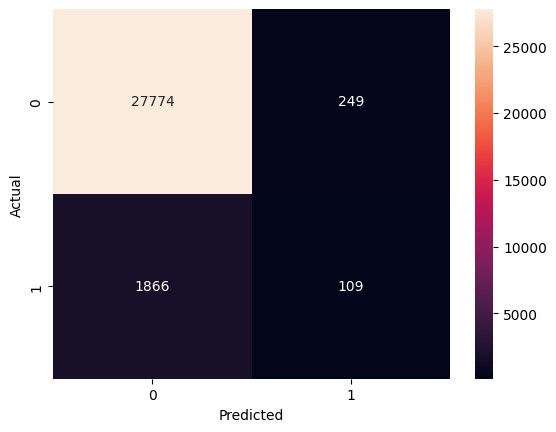

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

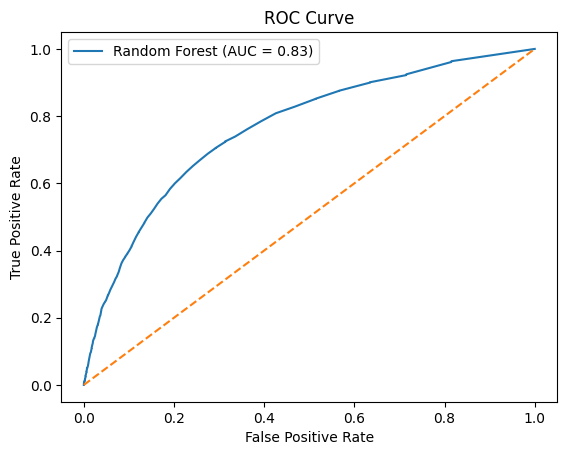

In [56]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr, tpr, label="Random Forest (AUC = 0.83)")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

pipeline.fit(X, y)

joblib.dump(pipeline, "credit_pipeline.pkl")

['credit_pipeline.pkl']